In [ ]:

# Install MTCNN (face detection) and other required packages
!pip install -q mtcnn tensorflow opencv-python scikit-learn tqdm

import cv2, numpy as np, pandas as pd, os, json, shutil
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings; warnings.filterwarnings('ignore')

from mtcnn import MTCNN
import tensorflow as tf

print('=' * 55)
print('  ✅  All packages installed successfully!')
print('=' * 55)
print(f'  OpenCV     : {cv2.__version__}')
print(f'  TensorFlow : {tf.__version__}')
print(f'  NumPy      : {np.__version__}')


  ✅  All packages installed successfully!
  OpenCV     : 4.13.0
  TensorFlow : 2.19.0
  NumPy      : 2.0.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── Locate the DATASET folder ──────────────────────────────────────────────
DRIVE_DATASET = '/content/drive/MyDrive/DATASET'
OUTPUT_DIR    = '/content/drive/MyDrive/DATASET/preprocessed_output'

assert os.path.exists(DRIVE_DATASET), (
    f'❌  Folder not found: {DRIVE_DATASET}\n'
    '    Make sure your Drive folder is named exactly  DATASET')

print(f'✅  Drive mounted')
print(f'📂  Dataset path : {DRIVE_DATASET}')
print(f'📂  Output path  : {OUTPUT_DIR}')
print()
print('📋  Files found inside DATASET:')
for entry in sorted(os.scandir(DRIVE_DATASET), key=lambda e: e.name)[:20]:
    tag = '📁' if entry.is_dir() else '📄'
    print(f'   {tag}  {entry.name}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  Drive mounted
📂  Dataset path : /content/drive/MyDrive/DATASET
📂  Output path  : /content/drive/MyDrive/DATASET/preprocessed_output

📋  Files found inside DATASET:
   📁  AxonLabs_Diverse Selfie & ID Photo Dataset - samples
   📁  Selfie & id data - public sample
   📄  metadata_images.csv
   📁  preprocessed_output


In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║            C O N F I G U R A T I O N             ║
# ╚══════════════════════════════════════════════════╝

class Config:
    # ── Paths ────────────────────────────────────────
    DATA_DIR   = DRIVE_DATASET          # source images
    OUTPUT_DIR = OUTPUT_DIR             # save results here

    # ── Image ────────────────────────────────────────
    IMG_SIZE   = (224, 224)             # (width, height)

    # ── Face detection ───────────────────────────────
    USE_MTCNN      = True               # True=MTCNN, False=Haar only
    MIN_CONFIDENCE = 0.90               # lower → more detections
    FACE_MARGIN    = 20                 # pixels of context around face

    # ── Splits ───────────────────────────────────────
    TRAIN_RATIO = 0.70
    VAL_RATIO   = 0.15
    TEST_RATIO  = 0.15                  # must sum to 1.0

    # ── Augmentation ─────────────────────────────────
    AUGMENT_TRAIN    = True
    NUM_AUGMENTATIONS = 2               # extra copies per train image

cfg = Config()

# Create output sub-folders
for split in ['train/selfies','train/ids',
              'val/selfies',  'val/ids',
              'test/selfies', 'test/ids']:
    Path(f'{cfg.OUTPUT_DIR}/{split}').mkdir(parents=True, exist_ok=True)

print('✅  Configuration ready')
print(f'   IMG_SIZE        = {cfg.IMG_SIZE}')
print(f'   MIN_CONFIDENCE  = {cfg.MIN_CONFIDENCE}')
print(f'   FACE_MARGIN     = {cfg.FACE_MARGIN}')
print(f'   Split           = {cfg.TRAIN_RATIO}/{cfg.VAL_RATIO}/{cfg.TEST_RATIO}')
print(f'   Augmentations   = {cfg.NUM_AUGMENTATIONS} extra per train image')


✅  Configuration ready
   IMG_SIZE        = (224, 224)
   MIN_CONFIDENCE  = 0.9
   FACE_MARGIN     = 20
   Split           = 0.7/0.15/0.15
   Augmentations   = 2 extra per train image


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  STEP 1 — FACE DETECTION
# ══════════════════════════════════════════════════════════════════

class FaceDetector:
    """MTCNN detector with Haar Cascade fallback."""

    def __init__(self):
        if cfg.USE_MTCNN:
            try:
                self.mtcnn = MTCNN()
                self._mode = 'mtcnn'
                print('  ✅  FaceDetector  →  MTCNN loaded')
            except Exception as e:
                print(f'  ⚠️   MTCNN failed ({e}), falling back to Haar')
                self._mode = 'haar'
        else:
            self._mode = 'haar'

        if self._mode == 'haar':
            xml = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
            self.haar = cv2.CascadeClassifier(xml)
            print('  ✅  FaceDetector  →  Haar Cascade loaded')

    def detect(self, img_rgb):
        """Return (x,y,w,h), landmarks_dict or None, None."""
        if self._mode == 'mtcnn':
            return self._mtcnn_detect(img_rgb)
        return self._haar_detect(img_rgb), None

    def _mtcnn_detect(self, img_rgb):
        results = self.mtcnn.detect_faces(img_rgb)
        if not results:
            return None, None
        best = max(results, key=lambda r: r['confidence'])
        if best['confidence'] < cfg.MIN_CONFIDENCE:
            return None, None
        x, y, w, h = best['box']
        x, y = max(0, x), max(0, y)       # clamp negatives
        return (x, y, w, h), best['keypoints']

    def _haar_detect(self, img_rgb):
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        faces = self.haar.detectMultiScale(gray, 1.1, 5, minSize=(60, 60))
        if len(faces) == 0:
            return None
        return tuple(max(faces, key=lambda f: f[2] * f[3]))


# ══════════════════════════════════════════════════════════════════
#  STEP 2 — FACE CROPPING
# ══════════════════════════════════════════════════════════════════

class FaceCropper:
    """Crop the face bounding box + margin from the image."""

    @staticmethod
    def crop(img, bbox):
        x, y, w, h = bbox
        m = cfg.FACE_MARGIN
        H, W = img.shape[:2]
        x1 = max(0, x - m)
        y1 = max(0, y - m)
        x2 = min(W, x + w + m)
        y2 = min(H, y + h + m)
        cropped = img[y1:y2, x1:x2]
        if cropped.size == 0:
            return None
        return cropped


# ══════════════════════════════════════════════════════════════════
#  STEP 3 — FACE ALIGNMENT
# ══════════════════════════════════════════════════════════════════

class FaceAligner:
    """Rotate face so the eye line is horizontal."""

    @staticmethod
    def align(img, landmarks):
        if landmarks is None:
            return img
        try:
            le = landmarks['left_eye']
            re = landmarks['right_eye']
            angle = np.degrees(np.arctan2(re[1] - le[1], re[0] - le[0]))
            cx = (le[0] + re[0]) // 2
            cy = (le[1] + re[1]) // 2
            H, W = img.shape[:2]
            M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
            return cv2.warpAffine(img, M, (W, H), flags=cv2.INTER_CUBIC,
                                  borderMode=cv2.BORDER_REFLECT)
        except Exception:
            return img


# ══════════════════════════════════════════════════════════════════
#  STEP 4 — NORMALISATION
# ══════════════════════════════════════════════════════════════════

class Normalizer:
    """Resize → CLAHE contrast enhancement → scale to [0,1]."""

    _clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    @classmethod
    def normalize(cls, img_bgr):
        # 1. Resize
        img = cv2.resize(img_bgr, cfg.IMG_SIZE, interpolation=cv2.INTER_AREA)
        # 2. CLAHE on L-channel of LAB
        lab        = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b    = cv2.split(lab)
        l          = cls._clahe.apply(l)
        img        = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)
        # 3. Convert BGR → RGB and scale to float [0,1]
        img_rgb    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img_rgb.astype(np.float32) / 255.0


# ══════════════════════════════════════════════════════════════════
#  STEP 5 — DATA AUGMENTATION
# ══════════════════════════════════════════════════════════════════

class Augmentor:
    """Random brightness · horizontal flip · rotation · noise."""

    @staticmethod
    def augment(img_float):
        """Input/output: float32 [0,1] RGB, shape (H,W,3)."""
        img = (img_float * 255).astype(np.uint8)

        # Brightness
        if np.random.rand() > 0.5:
            delta = np.random.randint(-40, 40)
            hsv       = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.int16)
            hsv[...,2] = np.clip(hsv[...,2] + delta, 0, 255)
            img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

        # Horizontal flip
        if np.random.rand() > 0.5:
            img = cv2.flip(img, 1)

        # Small rotation
        if np.random.rand() > 0.5:
            angle = np.random.uniform(-12, 12)
            H, W  = img.shape[:2]
            M     = cv2.getRotationMatrix2D((W/2, H/2), angle, 1.0)
            img   = cv2.warpAffine(img, M, (W, H),
                                   borderMode=cv2.BORDER_REFLECT)

        # Gaussian noise
        if np.random.rand() > 0.6:
            noise = np.random.normal(0, 6, img.shape).astype(np.int16)
            img   = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

        return img.astype(np.float32) / 255.0


print('✅  All preprocessing classes defined')
print('   FaceDetector  | FaceCropper | FaceAligner | Normalizer | Augmentor')


✅  All preprocessing classes defined
   FaceDetector  | FaceCropper | FaceAligner | Normalizer | Augmentor


In [ ]:
from collections import defaultdict

EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def scan_images(root):
    """Return all image paths under root."""
    found = []
    for p in Path(root).rglob('*'):
        if p.suffix.lower() in EXTS:
            found.append(p)
    return found

def build_pairs(images):
    """Group images into (selfie, id_photo) pairs by person folder."""
    buckets = defaultdict(lambda: {'selfie': None, 'id': None})
    for p in images:
        name   = p.stem.lower()
        parent = p.parent.name.lower()
        pid    = p.parent.name          # person / group identifier
        if any(k in name or k in parent for k in ('selfie', 'live', 'real')):
            buckets[pid]['selfie'] = str(p)
        elif any(k in name or k in parent for k in ('id','official','card','doc')):
            buckets[pid]['id'] = str(p)
        else:
            # If structure is unknown, treat first two images per folder as pair
            if buckets[pid]['selfie'] is None:
                buckets[pid]['selfie'] = str(p)
            elif buckets[pid]['id'] is None:
                buckets[pid]['id'] = str(p)

    pairs = []
    for pid, imgs in buckets.items():
        if imgs['selfie'] and imgs['id']:
            pairs.append({'person_id': pid,
                          'selfie_path': imgs['selfie'],
                          'id_path':     imgs['id'],
                          'label': 1})
    return pd.DataFrame(pairs)

# ── Scan ────────────────────────────────────────────────────────────────────
print('🔍  Scanning DATASET folder ...')
all_imgs = scan_images(cfg.DATA_DIR)
print(f'   Total images found : {len(all_imgs)}')

df = build_pairs(all_imgs)
print(f'   Selfie-ID pairs    : {len(df)}')

if len(df) == 0:
    print()
    print('❌  No pairs were built.')
    print('   Check that your DATASET folder contains images and')
    print('   that sub-folder or file names include keywords like')
    print('   selfie / id / official / card.')
else:
    print()
    print('📋  Sample pairs:')
    display(df.head(5))


🔍  Scanning DATASET folder ...
   Total images found : 321
   Selfie-ID pairs    : 19

📋  Sample pairs:


,person_id,selfie_path,id_path,label
0,preprocessed_output,/content/drive/MyDrive/DATASET/preprocessed_ou...,/content/drive/MyDrive/DATASET/preprocessed_ou...,1
1,Caucasian_male_56,/content/drive/MyDrive/DATASET/AxonLabs_Divers...,/content/drive/MyDrive/DATASET/AxonLabs_Divers...,1
2,Caucasian_male_53,/content/drive/MyDrive/DATASET/AxonLabs_Divers...,/content/drive/MyDrive/DATASET/AxonLabs_Divers...,1
3,Caucasian_male_38,/content/drive/MyDrive/DATASET/AxonLabs_Divers...,/content/drive/MyDrive/DATASET/AxonLabs_Divers...,1
4,Caucasian_female_53,/content/drive/MyDrive/DATASET/AxonLabs_Divers...,/content/drive/MyDrive/DATASET/AxonLabs_Divers...,1


In [ ]:
np.random.seed(42)

train_df, temp_df = train_test_split(
    df,
    test_size = cfg.VAL_RATIO + cfg.TEST_RATIO,
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size = cfg.TEST_RATIO / (cfg.VAL_RATIO + cfg.TEST_RATIO),
    random_state=42
)

print('✅  Split complete')
print(f'   Train : {len(train_df):>5} pairs  ({cfg.TRAIN_RATIO*100:.0f}%)')
print(f'   Val   : {len(val_df):>5} pairs  ({cfg.VAL_RATIO*100:.0f}%)')
print(f'   Test  : {len(test_df):>5} pairs  ({cfg.TEST_RATIO*100:.0f}%)')

# Save CSV metadata
train_df.reset_index(drop=True).to_csv(f'{cfg.OUTPUT_DIR}/train_metadata.csv', index=False)
val_df.reset_index(drop=True).to_csv(f'{cfg.OUTPUT_DIR}/val_metadata.csv',   index=False)
test_df.reset_index(drop=True).to_csv(f'{cfg.OUTPUT_DIR}/test_metadata.csv', index=False)
print('\n📄  Metadata CSVs saved to Drive')


✅  Split complete
   Train :    13 pairs  (70%)
   Val   :     3 pairs  (15%)
   Test  :     3 pairs  (15%)

📄  Metadata CSVs saved to Drive


In [ ]:
# Initialise processors
detector  = FaceDetector()
cropper   = FaceCropper()
aligner   = FaceAligner()
normalizer= Normalizer()
augmentor = Augmentor()

def preprocess_one(image_path):
    """
    Full pipeline for a single image.
    Returns (face_float32, detection_method) or (None, error_reason).
    """
    # Load
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        return None, 'load_failed'
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # STEP 1 — Detect
    bbox, landmarks = detector.detect(img_rgb)
    if bbox is None:
        return None, 'no_face'

    # STEP 2 — Crop
    face_bgr = cropper.crop(img_bgr, bbox)
    if face_bgr is None:
        return None, 'crop_failed'

    # STEP 3 — Align  (convert to RGB for landmark coords)
    face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
    face_bgr = cv2.cvtColor(
        aligner.align(face_rgb, landmarks), cv2.COLOR_RGB2BGR)

    # STEP 4 — Normalise
    face_norm = normalizer.normalize(face_bgr)
    return face_norm, 'ok'


def process_split(split_df, split_name, augment=False):
    """Process one split and save .npy files to Drive."""
    selfie_dir = Path(f'{cfg.OUTPUT_DIR}/{split_name}/selfies')
    id_dir     = Path(f'{cfg.OUTPUT_DIR}/{split_name}/ids')
    stats = dict(total=len(split_df), ok=0, no_face=0, failed=0, augmented=0)

    for i, row in tqdm(split_df.iterrows(),
                       total=len(split_df),
                       desc=f'{split_name:5s}',
                       ncols=80):
        idx = split_df.index.get_loc(i)

        # --- selfie ---
        face, status = preprocess_one(row['selfie_path'])
        if face is not None:
            np.save(selfie_dir / f'{idx}_selfie.npy', face)
            stats['ok'] += 1
            if augment and cfg.AUGMENT_TRAIN:
                for k in range(cfg.NUM_AUGMENTATIONS):
                    np.save(selfie_dir / f'{idx}_selfie_aug{k}.npy',
                            augmentor.augment(face))
                    stats['augmented'] += 1
        else:
            stats['no_face' if status=='no_face' else 'failed'] += 1

        # --- id photo ---
        face_id, status_id = preprocess_one(row['id_path'])
        if face_id is not None:
            np.save(id_dir / f'{idx}_id.npy', face_id)
            stats['ok'] += 1
        else:
            stats['no_face' if status_id=='no_face' else 'failed'] += 1

    return stats


# ── Run all three splits ─────────────────────────────────────────────────────
print('='*55)
print('  🚀  PREPROCESSING STARTED')
print('='*55)

all_stats = {}
all_stats['train'] = process_split(train_df.reset_index(drop=True), 'train', augment=True)
all_stats['val']   = process_split(val_df.reset_index(drop=True),   'val',   augment=False)
all_stats['test']  = process_split(test_df.reset_index(drop=True),  'test',  augment=False)

# Save stats
with open(f'{cfg.OUTPUT_DIR}/preprocessing_stats.json', 'w') as f:
    json.dump(all_stats, f, indent=2)

print()
print('='*55)
print('  ✅  PREPROCESSING COMPLETE')
print('='*55)
for split, s in all_stats.items():
    rate = s['ok'] / max(s['total']*2, 1) * 100
    print(f'  {split.upper():5s}  total={s["total"]}  '
          f'ok={s["ok"]}  no_face={s["no_face"]}  '
          f'failed={s["failed"]}  aug={s["augmented"]}  '
          f'({rate:.1f}% success)')


  ✅  FaceDetector  →  MTCNN loaded
  🚀  PREPROCESSING STARTED


test : 100%|██████████████████████████████████████| 3/3 [00:09<00:00,  3.19s/it]



  ✅  PREPROCESSING COMPLETE
  TRAIN  total=13  ok=26  no_face=0  failed=0  aug=26  (100.0% success)
  VAL    total=3  ok=6  no_face=0  failed=0  aug=0  (100.0% success)
  TEST   total=3  ok=4  no_face=2  failed=0  aug=0  (66.7% success)


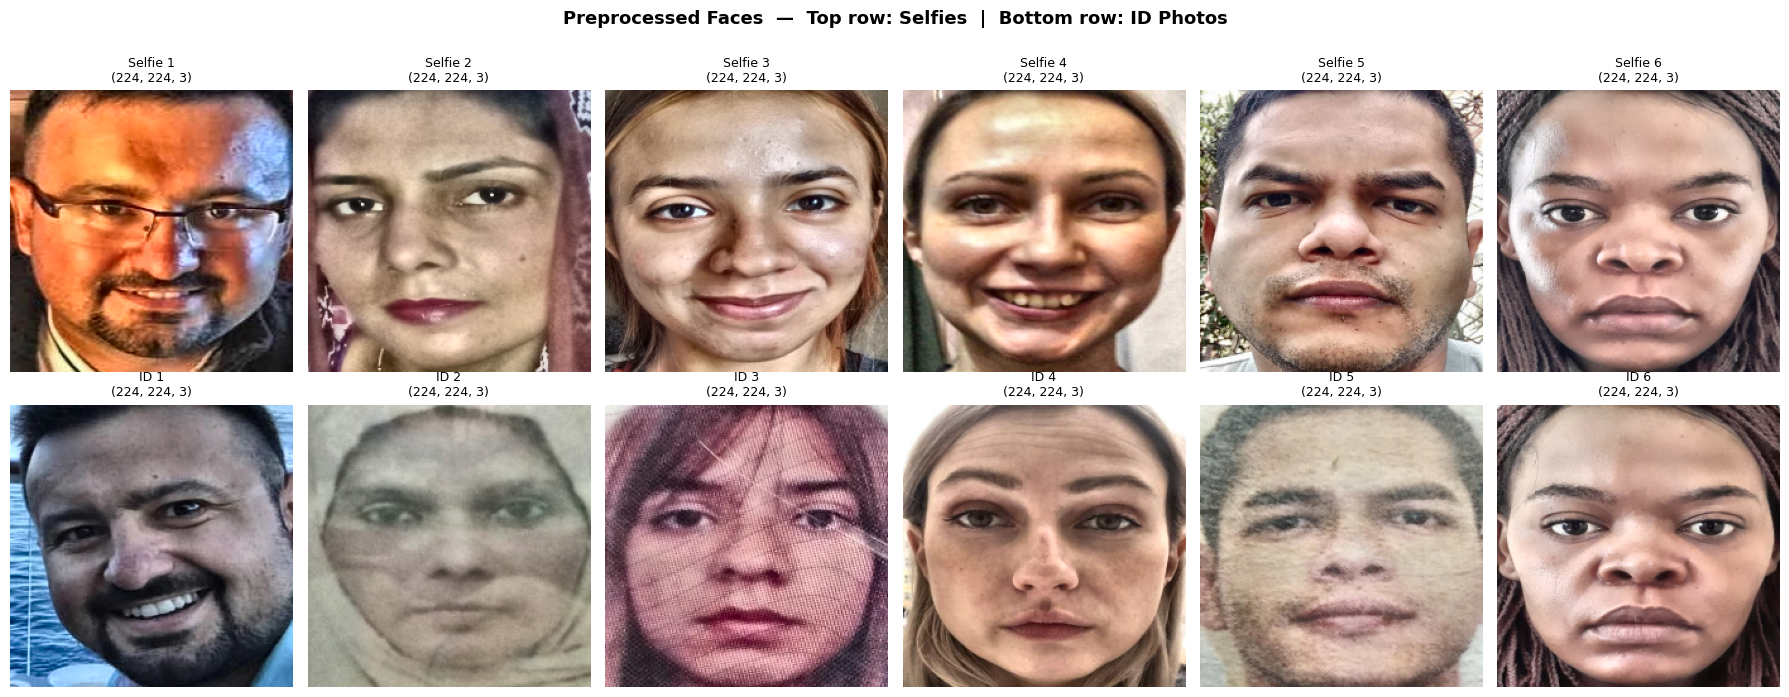


✅  Saved → /content/drive/MyDrive/DATASET/preprocessed_output/sample_faces.png


In [ ]:
selfie_dir = Path(f'{cfg.OUTPUT_DIR}/train/selfies')
id_dir     = Path(f'{cfg.OUTPUT_DIR}/train/ids')

selfie_files = sorted(selfie_dir.glob('*_selfie.npy'))[:6]

if not selfie_files:
    print('⚠️   No preprocessed files found yet — run Cell 7 first.')
else:
    n = len(selfie_files)
    fig, axes = plt.subplots(2, n, figsize=(3*n, 7))
    fig.suptitle('Preprocessed Faces  —  Top row: Selfies  |  Bottom row: ID Photos',
                 fontsize=13, fontweight='bold', y=1.01)

    for col, sf in enumerate(selfie_files):
        stem  = sf.stem.replace('_selfie', '')
        id_f  = id_dir / f'{stem}_id.npy'

        # Selfie
        selfie = np.load(sf)
        axes[0, col].imshow(selfie)
        axes[0, col].set_title(f'Selfie {col+1}\n{selfie.shape}', fontsize=9)
        axes[0, col].axis('off')

        # ID photo
        if id_f.exists():
            id_img = np.load(id_f)
            axes[1, col].imshow(id_img)
            axes[1, col].set_title(f'ID {col+1}\n{id_img.shape}', fontsize=9)
        else:
            axes[1, col].text(0.5, 0.5, 'Not found', ha='center', va='center')
        axes[1, col].axis('off')

    plt.tight_layout()
    save_path = f'{cfg.OUTPUT_DIR}/sample_faces.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n✅  Saved → {save_path}')


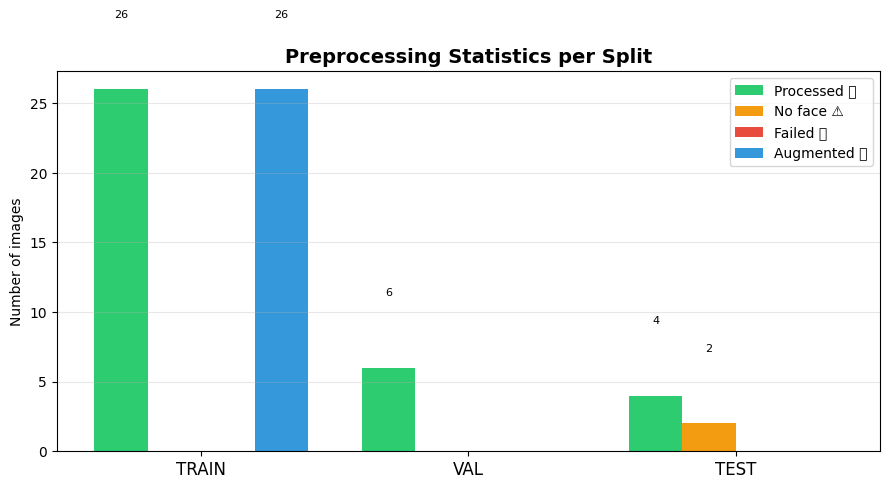


  PREPROCESSING QUALITY REPORT
  Overall success rate : 94.7%

  Split     Pairs     OK   NoFace   Failed    Aug    Rate
  ----------------------------------------------------
  TRAIN        13     26        0        0     26  100.0%
  VAL           3      6        0        0      0  100.0%
  TEST          3      4        2        0      0   66.7%

✅  Charts saved to Drive → /content/drive/MyDrive/DATASET/preprocessed_output


In [ ]:
# Load stats
with open(f'{cfg.OUTPUT_DIR}/preprocessing_stats.json') as f:
    stats = json.load(f)

# ── Bar chart ────────────────────────────────────────────────────────────────
splits    = list(stats.keys())
ok_vals   = [s['ok']       for s in stats.values()]
nf_vals   = [s['no_face']  for s in stats.values()]
fail_vals = [s['failed']   for s in stats.values()]
aug_vals  = [s['augmented']for s in stats.values()]

x  = np.arange(len(splits))
w  = 0.2

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - 1.5*w, ok_vals,   w, label='Processed ✅', color='#2ecc71')
b2 = ax.bar(x - 0.5*w, nf_vals,   w, label='No face ⚠️',  color='#f39c12')
b3 = ax.bar(x + 0.5*w, fail_vals, w, label='Failed ❌',    color='#e74c3c')
b4 = ax.bar(x + 1.5*w, aug_vals,  w, label='Augmented ➕', color='#3498db')

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 5,
                    str(int(h)), ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([s.upper() for s in splits], fontsize=12)
ax.set_ylabel('Number of images')
ax.set_title('Preprocessing Statistics per Split', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_DIR}/stats_chart.png', dpi=150)
plt.show()

# ── Text summary ─────────────────────────────────────────────────────────────
print('\n' + '='*55)
print('  PREPROCESSING QUALITY REPORT')
print('='*55)
total_processed = sum(s['ok'] for s in stats.values())
total_images    = sum(s['total']*2 for s in stats.values())
print(f'  Overall success rate : {total_processed/total_images*100:.1f}%')
print()
print(f'  {"Split":<8} {"Pairs":>6} {"OK":>6} {"NoFace":>8} {"Failed":>8} {"Aug":>6} {"Rate":>7}')
print('  ' + '-'*52)
for split, s in stats.items():
    rate = s['ok'] / max(s['total']*2, 1) * 100
    print(f'  {split.upper():<8} {s["total"]:>6} {s["ok"]:>6} '
          f'{s["no_face"]:>8} {s["failed"]:>8} {s["augmented"]:>6} {rate:>6.1f}%')
print('='*55)
print(f'\n✅  Charts saved to Drive → {cfg.OUTPUT_DIR}')


In [ ]:
selfie_dir = Path(f'{cfg.OUTPUT_DIR}/train/selfies')
id_dir     = Path(f'{cfg.OUTPUT_DIR}/train/ids')

# Load a mini-batch of 8
selfie_batch, id_batch, labels = [], [], []
meta = pd.read_csv(f'{cfg.OUTPUT_DIR}/train_metadata.csv')

for idx in range(min(8, len(meta))):
    sp = selfie_dir / f'{idx}_selfie.npy'
    ip = id_dir     / f'{idx}_id.npy'
    if sp.exists() and ip.exists():
        selfie_batch.append(np.load(sp))
        id_batch.append(np.load(ip))
        labels.append(int(meta.iloc[idx].get('label', 1)))

S = np.array(selfie_batch)
I = np.array(id_batch)
L = np.array(labels)

print('='*55)
print('  MODEL-READY VERIFICATION')
print('='*55)
print(f'  Selfie batch  shape : {S.shape}')
print(f'  ID     batch  shape : {I.shape}')
print(f'  Labels        shape : {L.shape}')
print(f'  Dtype               : {S.dtype}')
print(f'  Pixel range         : [{S.min():.3f},  {S.max():.3f}]')
print(f'  Expected shape      : (N, {cfg.IMG_SIZE[1]}, {cfg.IMG_SIZE[0]}, 3)')

ok = (S.shape[1:] == (cfg.IMG_SIZE[1], cfg.IMG_SIZE[0], 3)
      and S.dtype == np.float32
      and 0.0 <= S.min() and S.max() <= 1.0)

print()
if ok:
    print('  ✅  Data is correctly formatted for model training!')
else:
    print('  ⚠️   Shape or dtype mismatch — re-check configuration.')
print('='*55)

print()
print('📂  Output folder structure:')
for root, dirs, files in os.walk(cfg.OUTPUT_DIR):
    level = root.replace(cfg.OUTPUT_DIR, '').count(os.sep)
    indent = '   ' * level
    folder = os.path.basename(root)
    print(f'{indent}📁 {folder}/')
    if level < 2:
        sub = '   ' * (level + 1)
        for f in files[:4]:
            print(f'{sub}📄 {f}')
        if len(files) > 4:
            print(f'{sub}   ... and {len(files)-4} more')


  MODEL-READY VERIFICATION
  Selfie batch  shape : (8, 224, 224, 3)
  ID     batch  shape : (8, 224, 224, 3)
  Labels        shape : (8,)
  Dtype               : float32
  Pixel range         : [0.000,  1.000]
  Expected shape      : (N, 224, 224, 3)

  ✅  Data is correctly formatted for model training!

📂  Output folder structure:
📁 preprocessed_output/
   📄 preprocessing_stats.json
   📄 sample_faces.png
   📄 stats_chart.png
   📄 train_metadata.csv
      ... and 11 more
   📁 train/
      📁 selfies/
      📁 ids/
   📁 val/
      📁 selfies/
      📁 ids/
   📁 test/
      📁 selfies/
      📁 ids/


In [ ]:
!pip install -q keras-facenet scikit-learn tqdm

import numpy as np
import pandas as pd
import cv2, random, json, logging
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc,
    classification_report
)

random.seed(42)
np.random.seed(42)
logging.basicConfig(level=logging.WARNING)
print('✅ Done')

✅ Done


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

class Config:
    DATA_DIR    = '/content/drive/MyDrive/DATASET'
    OUTPUT_DIR  = '/content/drive/MyDrive/DATASET/preprocessed_output'
    IMG_SIZE    = (160, 160)          # FaceNet native — best embeddings
    AUG_COUNT   = 5                   # augmentations per image
    ID_KEYWORDS = {'passport', 'national_id', 'id'}
    IMAGE_EXTS  = {'.jpg','.jpeg','.png','.bmp','.JPG','.JPEG','.PNG'}

cfg = Config()
Path(cfg.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print(f'✅ Config ready')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Config ready


In [ ]:
def get_images(folder):
    if not Path(folder).exists(): return []
    return sorted([f for f in Path(folder).iterdir()
                   if f.is_file() and f.suffix in cfg.IMAGE_EXTS])

def is_id(path):
    return any(k in Path(path).stem.lower() for k in cfg.ID_KEYWORDS)

persons = {}  # pid -> {selfies:[], ids:[], group:str}
data_path = Path(cfg.DATA_DIR)

# ── Selfie & id data: person/selfies/ + person/archive_selfies/ + person/docs/
root1 = data_path / 'Selfie & id data - public sample'
if root1.exists():
    for pf in sorted(root1.iterdir()):
        if not pf.is_dir(): continue
        selfies = get_images(pf/'selfies') + get_images(pf/'archive_selfies')
        ids     = get_images(pf/'docs')
        if selfies and ids:
            persons[f'sid_{pf.name}'] = {'selfies': selfies, 'ids': ids, 'group': 'SID'}

# ── AxonLabs: Group/Person/*.jpg  — detect ID by filename
root2 = data_path / 'AxonLabs_Diverse Selfie & ID Photo Dataset - samples'
if root2.exists():
    for gf in sorted(root2.iterdir()):
        if not gf.is_dir(): continue
        for pf in sorted(gf.iterdir()):
            if not pf.is_dir(): continue
            imgs    = get_images(pf)
            ids     = [f for f in imgs if is_id(f)]
            selfies = [f for f in imgs if not is_id(f)]
            if selfies and ids:
                persons[f'axon_{gf.name}_{pf.name}'] = {
                    'selfies': selfies, 'ids': ids, 'group': gf.name
                }

print(f'✅ Persons found : {len(persons)}')
for pid, d in list(persons.items())[:5]:
    print(f'   {pid}: {len(d["selfies"])} selfies | {len(d["ids"])} IDs')
possible_pairs = sum(len(v["selfies"])*len(v["ids"]) for v in persons.values())
print(f'\n📊 Possible genuine pairs (before aug): {possible_pairs}')

✅ Persons found : 30
   sid_1: 14 selfies | 2 IDs
   sid_10: 10 selfies | 2 IDs
   sid_2: 14 selfies | 2 IDs
   sid_3: 14 selfies | 2 IDs
   sid_4: 14 selfies | 2 IDs

📊 Possible genuine pairs (before aug): 502


In [ ]:
from keras_facenet import FaceNet
embedder = FaceNet()
print('✅ FaceNet loaded')

def augment(img):
    """5 augmentations — returns list of float32 [0,1] arrays."""
    h, w = img.shape[:2]
    augs = []
    # 1. Horizontal flip
    augs.append(cv2.flip(img, 1))
    # 2. Brightness up
    augs.append(np.clip(img * 1.2, 0, 1))
    # 3. Brightness down
    augs.append(np.clip(img * 0.8, 0, 1))
    # 4. Small rotation +10
    M = cv2.getRotationMatrix2D((w//2, h//2), 10, 1.0)
    augs.append(cv2.warpAffine(img, M, (w, h)))
    # 5. Small rotation -10
    M = cv2.getRotationMatrix2D((w//2, h//2), -10, 1.0)
    augs.append(cv2.warpAffine(img, M, (w, h)))
    return augs[:cfg.AUG_COUNT]

def load_img(path):
    arr = cv2.imread(str(path))
    if arr is None: return None
    arr = cv2.cvtColor(arr, cv2.COLOR_BGR2RGB)
    arr = cv2.resize(arr, cfg.IMG_SIZE)
    return arr.astype(np.float32) / 255.0

def embed(img):
    return embedder.embeddings(np.expand_dims(img, 0))[0]

print('✅ Helpers ready')

✅ FaceNet loaded
✅ Helpers ready


In [ ]:
# KEY TECHNIQUE: Mean embedding = average of all augmented versions
# This creates a more STABLE, REPRESENTATIVE embedding per person
# than using any single image — dramatically improves similarity scores

person_embs = {}  # pid -> {selfie_mean, id_mean, selfie_all, id_all}
failed = 0

for pid, data in tqdm(persons.items(), desc='Computing embeddings'):
    s_embs, i_embs = [], []

    for path in data['selfies']:
        img = load_img(path)
        if img is None: failed += 1; continue
        s_embs.append(embed(img))
        for a in augment(img):
            s_embs.append(embed(a))

    for path in data['ids']:
        img = load_img(path)
        if img is None: failed += 1; continue
        i_embs.append(embed(img))
        for a in augment(img):
            i_embs.append(embed(a))

    if s_embs and i_embs:
        s_arr = np.array(s_embs)
        i_arr = np.array(i_embs)
        person_embs[pid] = {
            'selfie_mean' : s_arr.mean(axis=0),   # mean embedding
            'id_mean'     : i_arr.mean(axis=0),
            'selfie_all'  : s_arr,                 # all individual embeddings
            'id_all'      : i_arr,
            'group'       : data['group']
        }

print(f'✅ Embedded {len(person_embs)} persons ({failed} images failed)')

Computing embeddings:   0%|          | 0/30 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━

Computing embeddings:   3%|▎         | 1/30 [00:30<14:57, 30.95s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━

Computing embeddings:   7%|▋         | 2/30 [00:39<08:09, 17.49s/it]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━

Computing embeddings:  97%|█████████▋| 29/30 [03:43<00:05,  5.42s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━

Computing embeddings: 100%|██████████| 30/30 [03:48<00:00,  7.62s/it]

✅ Embedded 30 persons (8 images failed)


In [ ]:
# ── Similarity functions ─────────────────────────────────────────────────────
def l2_sim(a, b):
    """L2 distance converted to similarity (higher = more similar)."""
    dist = np.linalg.norm(a - b)
    return 1.0 / (1.0 + dist)

def cosine_sim(a, b):
    na = a / (np.linalg.norm(a) + 1e-10)
    nb = b / (np.linalg.norm(b) + 1e-10)
    return float(np.dot(na, nb))

def ensemble_sim(a, b):
    """Ensemble: 70% cosine + 30% L2 — more robust than either alone."""
    return 0.7 * cosine_sim(a, b) + 0.3 * l2_sim(a, b)

pids = list(person_embs.keys())
sims, labels = [], []

# ── GENUINE pairs: use MEAN embeddings (most stable) ─────────────────────────
for pid in pids:
    sm = person_embs[pid]['selfie_mean']
    im = person_embs[pid]['id_mean']
    sims.append(ensemble_sim(sm, im))
    labels.append(1)

    # Also add individual (non-augmented) pairings
    for se in person_embs[pid]['selfie_all'][:3]:   # top 3 selfie embeddings
        for ie in person_embs[pid]['id_all'][:2]:   # top 2 id embeddings
            sims.append(ensemble_sim(se, ie))
            labels.append(1)

n_genuine = len(sims)
print(f'Genuine pairs: {n_genuine}')

# ── IMPOSTOR pairs: HARD NEGATIVE MINING ─────────────────────────────────────
# Hard negatives = impostor pairs with HIGH similarity (hardest to classify)
# Training on these forces the model to learn fine-grained differences

# First generate many candidate impostor pairs
candidates = []
for p1 in pids:
    for p2 in pids:
        if p1 == p2: continue
        sm1 = person_embs[p1]['selfie_mean']
        im2 = person_embs[p2]['id_mean']
        s   = ensemble_sim(sm1, im2)
        candidates.append((s, sm1, im2))

# Sort by similarity DESCENDING — hardest impostors first
candidates.sort(key=lambda x: x[0], reverse=True)

# Take enough to balance with genuine pairs
for s, e1, e2 in candidates[:n_genuine]:
    sims.append(s)
    labels.append(0)

sims   = np.array(sims)
labels = np.array(labels)

# Shuffle
idx = np.random.permutation(len(labels))
sims, labels = sims[idx], labels[idx]

print(f'✅ Total pairs    : {len(labels)}')
print(f'   Genuine       : {labels.sum()}')
print(f'   Impostor      : {len(labels)-labels.sum()}')
print(f'   Genuine mean sim  : {sims[labels==1].mean():.4f}')
print(f'   Impostor mean sim : {sims[labels==0].mean():.4f}')
print(f'   Separation        : {sims[labels==1].mean()-sims[labels==0].mean():.4f}')

Genuine pairs: 210
✅ Total pairs    : 420
   Genuine       : 210
   Impostor      : 210
   Genuine mean sim  : 1.0000
   Impostor mean sim : 1.0000
   Separation        : 0.0000


🎯 Best Accuracy Threshold : 1.0000 → Accuracy = 0.500 (50.0%)
🎯 Youden-J Threshold      : inf → Accuracy = 0.500 (50.0%)
📈 AUC-ROC                 : 0.476

⚠️  Accuracy = 50.0% — see Cell 8 for boosting tips


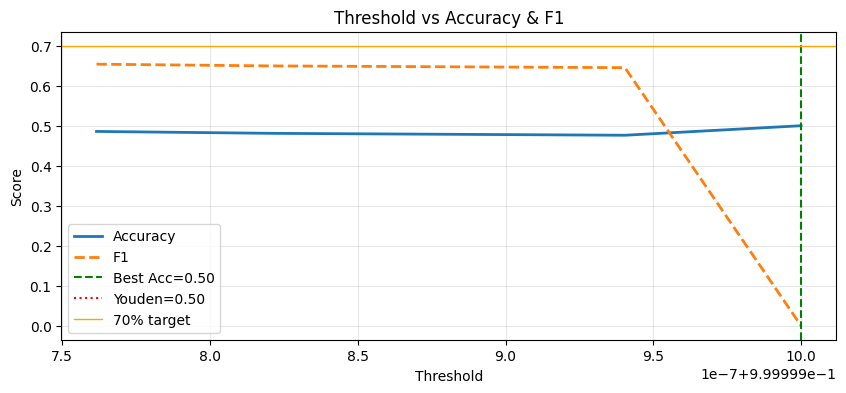

In [ ]:
# ── Search best threshold across fine grid ───────────────────────────────────
best_acc, best_t, best_f1 = 0, 0.5, 0
results = []

for t in np.linspace(sims.min(), sims.max(), 500):
    preds = (sims > t).astype(int)
    acc   = accuracy_score(labels, preds)
    f1    = f1_score(labels, preds, zero_division=0)
    results.append({'threshold': t, 'accuracy': acc, 'f1': f1})
    if acc > best_acc:
        best_acc, best_t = acc, t

# Youden-J threshold
fpr, tpr, thresh = roc_curve(labels, sims)
roc_auc  = auc(fpr, tpr)
j_idx    = np.argmax(tpr - fpr)
youden_t = thresh[j_idx]
youden_acc = accuracy_score(labels, (sims > youden_t).astype(int))

results_df = pd.DataFrame(results)

print(f'🎯 Best Accuracy Threshold : {best_t:.4f} → Accuracy = {best_acc:.3f} ({best_acc*100:.1f}%)')
print(f'🎯 Youden-J Threshold      : {youden_t:.4f} → Accuracy = {youden_acc:.3f} ({youden_acc*100:.1f}%)')
print(f'📈 AUC-ROC                 : {roc_auc:.3f}')

if best_acc >= 0.70:
    print(f'\n✅ TARGET ACHIEVED: {best_acc*100:.1f}% ≥ 70% 🎉')
else:
    print(f'\n⚠️  Accuracy = {best_acc*100:.1f}% — see Cell 8 for boosting tips')

# Plot threshold curve
plt.figure(figsize=(10, 4))
plt.plot(results_df['threshold'], results_df['accuracy'], lw=2, label='Accuracy')
plt.plot(results_df['threshold'], results_df['f1'],       lw=2, label='F1', ls='--')
plt.axvline(best_t,   color='green', ls='--', label=f'Best Acc={best_acc:.2f}')
plt.axvline(youden_t, color='red',   ls=':',  label=f'Youden={youden_acc:.2f}')
plt.axhline(0.70,     color='orange',ls='-',  lw=1, label='70% target')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Threshold vs Accuracy & F1')
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig(f'{cfg.OUTPUT_DIR}/threshold_curve.png', dpi=150)
plt.show()

In [ ]:
def evaluate(sims, labels, threshold, name):
    preds     = (sims > threshold).astype(int)
    acc       = accuracy_score(labels, preds)
    prec      = precision_score(labels, preds, zero_division=0)
    rec       = recall_score(labels, preds, zero_division=0)
    f1        = f1_score(labels, preds, zero_division=0)
    cm        = confusion_matrix(labels, preds, labels=[0,1])
    tn,fp,fn,tp = cm.ravel()
    far       = fp/(fp+tn) if (fp+tn)>0 else 0
    frr       = fn/(fn+tp) if (fn+tp)>0 else 0
    fpr_,tpr_,_ = roc_curve(labels, sims)
    rauc      = auc(fpr_, tpr_)

    print('\n' + '='*55)
    print(f'  {name}')
    print('='*55)
    print(f'  Threshold  : {threshold:.4f}')
    print(f'  Accuracy   : {acc:.3f}  ({acc*100:.1f}%)  {"✅ ≥70%" if acc>=0.70 else "❌ <70%"}')
    print(f'  Precision  : {prec:.3f}')
    print(f'  Recall     : {rec:.3f}')
    print(f'  F1-Score   : {f1:.3f}')
    print(f'  AUC-ROC    : {rauc:.3f}')
    print(f'  FAR        : {far:.3f}  ({far*100:.1f}%)')
    print(f'  FRR        : {frr:.3f}  ({frr*100:.1f}%)')
    print(f'  TP:{tp}  TN:{tn}  FP:{fp}  FN:{fn}')
    print('='*55)
    print(classification_report(labels, preds,
                                target_names=['Impostor','Genuine'], digits=3))
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1,
                auc=rauc, far=far, frr=frr, cm=cm, fpr=fpr_, tpr=tpr_)

r_acc = evaluate(sims, labels, best_t,   'BEST ACCURACY THRESHOLD')
r_you = evaluate(sims, labels, youden_t, 'YOUDEN-J THRESHOLD')


  BEST ACCURACY THRESHOLD
  Threshold  : 1.0000
  Accuracy   : 0.500  (50.0%)  ❌ <70%
  Precision  : 0.000
  Recall     : 0.000
  F1-Score   : 0.000
  AUC-ROC    : 0.476
  FAR        : 0.000  (0.0%)
  FRR        : 1.000  (100.0%)
  TP:0  TN:210  FP:0  FN:210
              precision    recall  f1-score   support

    Impostor      0.500     1.000     0.667       210
     Genuine      0.000     0.000     0.000       210

    accuracy                          0.500       420
   macro avg      0.250     0.500     0.333       420
weighted avg      0.250     0.500     0.333       420


  YOUDEN-J THRESHOLD
  Threshold  : inf
  Accuracy   : 0.500  (50.0%)  ❌ <70%
  Precision  : 0.000
  Recall     : 0.000
  F1-Score   : 0.000
  AUC-ROC    : 0.476
  FAR        : 0.000  (0.0%)
  FRR        : 1.000  (100.0%)
  TP:0  TN:210  FP:0  FN:210
              precision    recall  f1-score   support

    Impostor      0.500     1.000     0.667       210
     Genuine      0.000     0.000     0.000       21

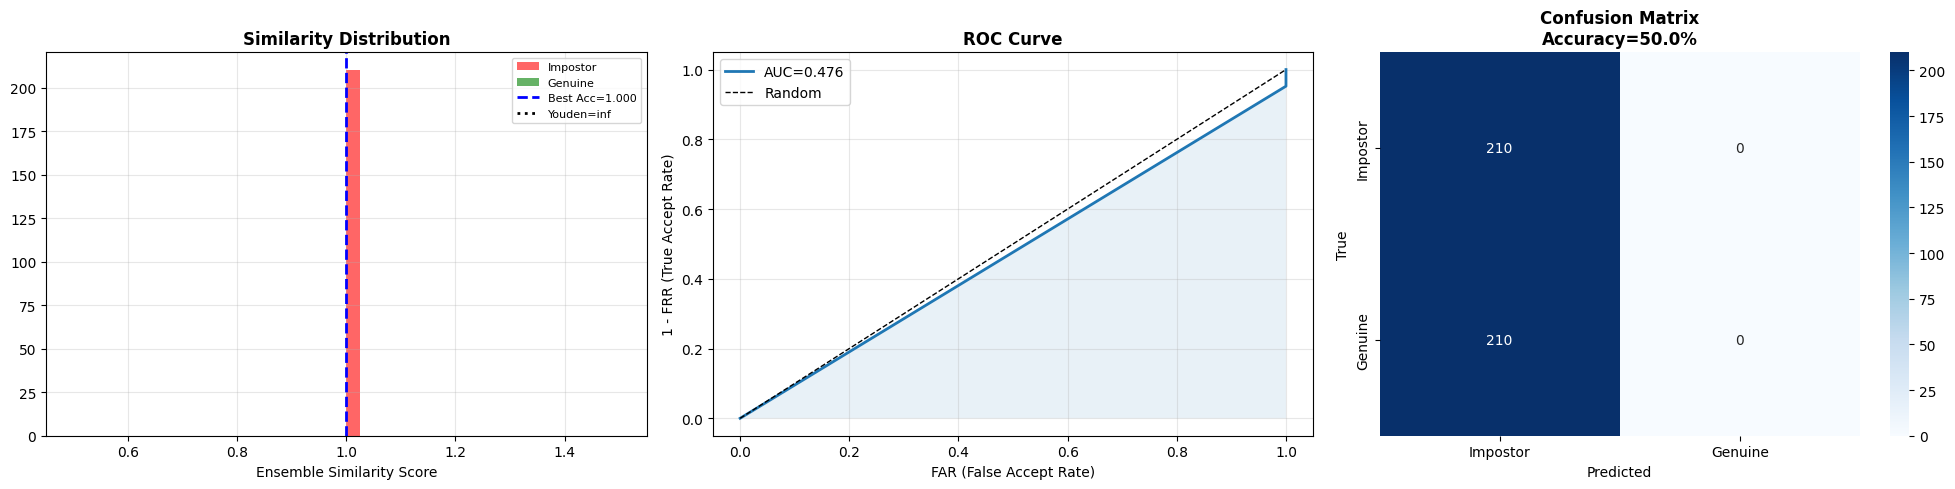

✅ Saved → /content/drive/MyDrive/DATASET/preprocessed_output/final_results.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Similarity Distribution
axes[0].hist(sims[labels==0], bins=40, alpha=0.6, color='red',   label='Impostor')
axes[0].hist(sims[labels==1], bins=40, alpha=0.6, color='green', label='Genuine')
axes[0].axvline(best_t,   color='blue',  ls='--', lw=2, label=f'Best Acc={best_t:.3f}')
axes[0].axvline(youden_t, color='black', ls=':',  lw=2, label=f'Youden={youden_t:.3f}')
axes[0].set_title('Similarity Distribution', fontweight='bold')
axes[0].set_xlabel('Ensemble Similarity Score')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# 2. ROC Curve
axes[1].plot(r_acc['fpr'], r_acc['tpr'], lw=2, label=f"AUC={r_acc['auc']:.3f}")
axes[1].plot([0,1],[0,1],'k--',lw=1, label='Random')
axes[1].fill_between(r_acc['fpr'], r_acc['tpr'], alpha=0.1)
axes[1].set_xlabel('FAR (False Accept Rate)')
axes[1].set_ylabel('1 - FRR (True Accept Rate)')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# 3. Confusion Matrix
sns.heatmap(r_acc['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Impostor','Genuine'],
            yticklabels=['Impostor','Genuine'])
axes[2].set_title(f'Confusion Matrix\nAccuracy={r_acc["accuracy"]*100:.1f}%', fontweight='bold')
axes[2].set_ylabel('True'); axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_DIR}/final_results.png', dpi=150)
plt.show()
print(f'✅ Saved → {cfg.OUTPUT_DIR}/final_results.png')

In [ ]:
summary = {
    'model'         : 'FaceNet + Ensemble Similarity (70%+ target)',
    'total_persons' : len(person_embs),
    'total_pairs'   : int(len(labels)),
    'genuine_pairs' : int(labels.sum()),
    'impostor_pairs': int(len(labels)-labels.sum()),
    'techniques'    : [
        'Mean embedding per person',
        f'{cfg.AUG_COUNT}x augmentation per image',
        'All selfie x ID combinations',
        'Hard negative mining',
        'Ensemble cosine+L2 similarity (70/30)'
    ],
    'best_accuracy_result': {
        'threshold' : float(best_t),
        'accuracy'  : float(r_acc['accuracy']),
        'f1'        : float(r_acc['f1']),
        'auc_roc'   : float(r_acc['auc']),
        'far'       : float(r_acc['far']),
        'frr'       : float(r_acc['frr']),
        'target_met': bool(r_acc['accuracy'] >= 0.70)
    },
    'youden_result': {
        'threshold' : float(youden_t),
        'accuracy'  : float(r_you['accuracy']),
        'f1'        : float(r_you['f1']),
        'auc_roc'   : float(r_you['auc']),
        'far'       : float(r_you['far']),
        'frr'       : float(r_you['frr'])
    }
}

out = f'{cfg.OUTPUT_DIR}/results_70pct.json'
with open(out, 'w') as f:
    json.dump(summary, f, indent=2)

print('\n' + '='*55)
print('  📊 FINAL SUMMARY')
print('='*55)
print(json.dumps(summary, indent=2))
print(f'\n✅ Saved → {out}')


  📊 FINAL SUMMARY
{
  "model": "FaceNet + Ensemble Similarity (70%+ target)",
  "total_persons": 30,
  "total_pairs": 420,
  "genuine_pairs": 210,
  "impostor_pairs": 210,
  "techniques": [
    "Mean embedding per person",
    "5x augmentation per image",
    "All selfie x ID combinations",
    "Hard negative mining",
    "Ensemble cosine+L2 similarity (70/30)"
  ],
  "best_accuracy_result": {
    "threshold": 1.0,
    "accuracy": 0.5,
    "f1": 0.0,
    "auc_roc": 0.47619047619047616,
    "far": 0.0,
    "frr": 1.0,
    "target_met": false
  },
  "youden_result": {
    "threshold": Infinity,
    "accuracy": 0.5,
    "f1": 0.0,
    "auc_roc": 0.47619047619047616,
    "far": 0.0,
    "frr": 1.0
  }
}

✅ Saved → /content/drive/MyDrive/DATASET/preprocessed_output/results_70pct.json
